In [18]:
import json
import os
import tempfile

import einops
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F
import wandb
from load_spd_model2 import load_spd_model
from multitask_sparse_parity import MultitaskSparseParityDataset, MultitaskSparseParityModel
from torch.utils.data import DataLoader
from train_mtsp_model_uniform_task_distribution_modal import TrainConfig
from upload_mtsp_checkpoints_to_wandb import UploadCheckpointsConfig
from wandb_utils import load_wandb_model_artifact

from spd.models.component_model import (
    ComponentModel,
    SPDRunInfo,
    handle_deprecated_state_dict_keys_,
)
from spd.models.components import make_mask_infos
from spd.utils.module_utils import expand_module_patterns

In [19]:
target_config, config, model = load_spd_model(
    "mutate/multitask-sparse-parity/runs/oniknm0t",  # d_mlp=14, n_control_bits=2, parity=2
    # "wandb:mutate/spd/runs/s-710cd5ea",
    # "wandb:mutate/spd/runs/s-630ccbc4",  # spd-77c2221f-step10000
    # "wandb:mutate/spd/runs/s-e948eb84",  # spd-77c2221f-step20000
    # "wandb:mutate/spd/runs/s-6d5129e4",  # spd-77c2221f-step30000
    # "wandb:mutate/spd/runs/s-80ac5bb0",  # spd-77c2221f-step40000
    # "wandb:mutate/spd/runs/s-3077dc03",  # spd-77c2221f-step50000
    # "wandb:mutate/spd/runs/s-eaff849d",  # spd-77c2221f-step60000
    # # "wandb:mutate/spd/runs/s-d30dc3c8",  # spd-77c2221f-step70000
    # "wandb:mutate/spd/runs/s-a7dcdbfe",  # spd-77c2221f-step80000
    "wandb:mutate/spd/runs/s-6fe153b3",  # spd-77c2221f-step90000
)

ComponentModel(
  (target_model): MultitaskSparseParityModel(
    (l1): Linear(in_features=32, out_features=14, bias=False)
    (l2): Linear(in_features=14, out_features=2, bias=False)
  )
  (_components): ModuleDict(
    (l1): LinearComponents()
  )
  (_ci_fns): ModuleDict(
    (l1): VectorSharedMLPCiFn(
      (layers): Sequential(
        (0): Linear()
        (1): GELU(approximate='none')
        (2): Linear()
      )
    )
  )
)
tensor(6.4960e-08)
tensor([[ -85.3032,  -67.7231],
        [ -90.6693, -107.3244],
        [ -93.0548,  -77.8349],
        [ -97.5399,  -80.8623],
        [ -68.7853,  -85.9496]])
tensor(6.4960e-08)
tensor(0) tensor([0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0,
        0, 0, 0, 1, 0, 0]) tensor(1)
torch.Size([1024, 200])
torch.Size([1024, 200])
loss_using_components=tensor(7.1782e-05, grad_fn=<NllLossBackward0>)
l1 tensor(0.0077)


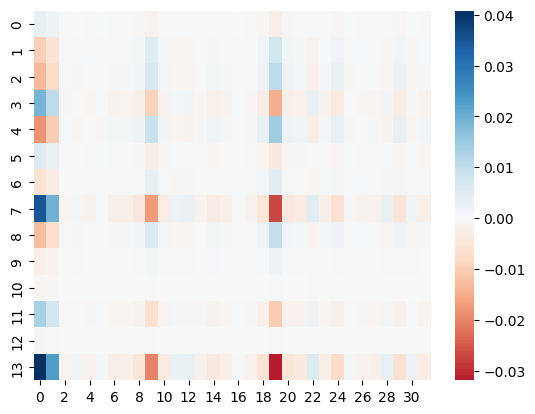

In [20]:
print(model)

dataloader = DataLoader(
    MultitaskSparseParityDataset(
        n_control_bits=target_config.n_control_bits,
        n_task_bits=target_config.n_task_bits,
        n_xored_bits=target_config.n_xored_bits,
        task_distribution_decay_rate=target_config.task_distribution_decay_rate,
        batch_sz=1024,
        size=None,
    ),
    batch_size=None,
)
torch.manual_seed(0)
batch = next(iter(dataloader))
task_ids, task_bits, targets = batch

loss = F.cross_entropy(model(batch), targets)
print(loss)


out = model(batch, cache_type="input")
print(out.output[:5, :])
loss = F.cross_entropy(out.output, targets)
print(loss)


ci_dict = model.calc_causal_importances(
    pre_weight_acts=out.cache,
    detach_inputs=True,
    sampling=config.sampling,
).lower_leaky

# print(ci_dict)

print(task_ids[0], task_bits[0], targets[0])

print(ci_dict["l1"].shape)

layer_names = list(model.target_module_paths)
ci = torch.cat([ci_dict[layer] for layer in layer_names], dim=1)

print(ci.shape)

component_ci_threshold = 0.9
mask_infos = make_mask_infos(
    # component_masks={k: torch.ones_like(v) for k, v in ci_dict.items()},
    # component_masks={k: v for k, v in ci_dict.items()},
    component_masks={k: (v > component_ci_threshold).float() for k, v in ci_dict.items()},
    routing_masks="all",
)

logits_using_components = model(batch, cache_type="input", mask_infos=mask_infos).output
loss_using_components = loss = F.cross_entropy(logits_using_components, targets)
print(f"{loss_using_components=}")

# loss_by_token_using_components = F.cross_entropy(
#     einops.rearrange(logits_using_components[:, :-1], "b seq vocab -> b vocab seq"),
#     batch[:, 1:],
#     reduction="none",
# )
# print(f"mean loss using components = {loss_by_token_using_components.mean().item()}")


for k, v in ci_dict.items():
    print(k, (v > component_ci_threshold).float().mean())


components = model.components["l1"]
einops.einsum(components.V[:, 0], components.U[0], "d_in, d_out -> d_out d_in")

idx = 0
sns.heatmap(
    einops.einsum(components.V[:, idx], components.U[idx], "d_in, d_out -> d_out d_in").detach(),
    cmap="RdBu",
    center=0,
)
plt.show()


In [21]:
idx

0

In [22]:
ci.mean(0).sort(descending=True)

torch.return_types.sort(
values=tensor([4.8437e-01, 2.1810e-01, 1.8452e-01, 1.8359e-01, 1.5184e-01, 1.4830e-01,
        8.5374e-02, 7.7148e-02, 7.4360e-02, 7.0298e-02, 7.0209e-02, 5.9196e-02,
        4.9073e-02, 1.7986e-02, 1.4968e-02, 1.2348e-02, 9.7895e-04, 7.3596e-04,
        4.0445e-04, 2.9221e-04, 4.0834e-05, 1.2362e-05, 6.8173e-06, 2.0024e-06,
        1.0897e-06, 6.3272e-07, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        

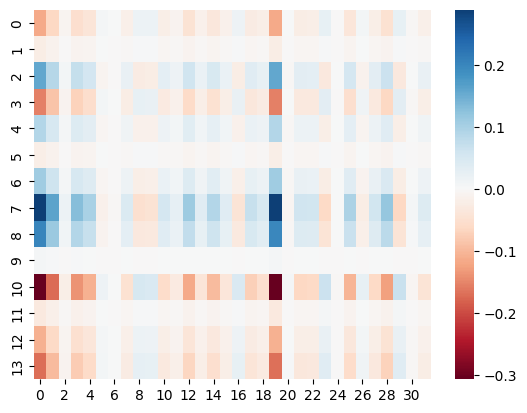

In [23]:
# idx = ci[task_ids == 0].mean(0).sort(descending=True).indices[1]
idx = ci.mean(0).sort(descending=True).indices[1]
# # idx = 73
# idx2 = 2
# print((ci + ((ci[task_ids == 1].mean(0) > 0) * -9999)).mean(0).sort(descending=True).values[idx2])
# idx = (ci + ((ci[task_ids == 1].mean(0) > 0) * -9999)).mean(0).sort(descending=True).indices[idx2]
sns.heatmap(
    einops.einsum(components.V[:, idx], components.U[idx], "d_in, d_out -> d_out d_in").detach(),
    cmap="RdBu",
    center=0,
)
plt.show()

In [24]:
ci.mean(0).sort(descending=True).values > 0

tensor([ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, 

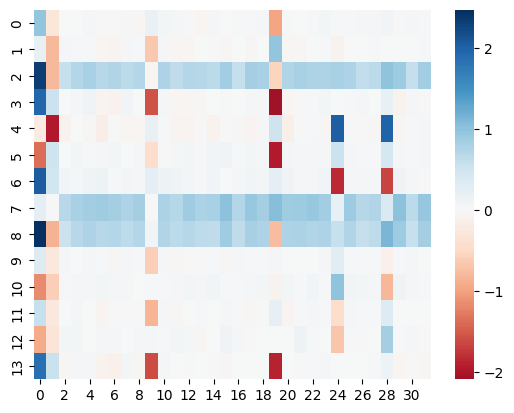

In [25]:
sns.heatmap(
    einops.einsum(
        components.V[:, ci.mean(0) == 0],
        components.U[ci.mean(0) == 0],
        "d_in c, c d_out -> d_out d_in",
    ).detach(),
    cmap="RdBu",
    center=0,
)
plt.show()

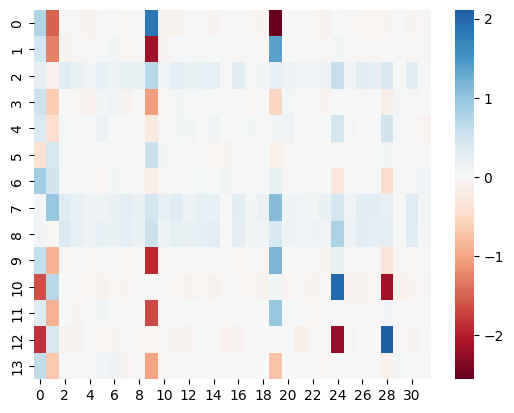

In [26]:
component_mask = ci.mean(0) > 0
sns.heatmap(
    einops.einsum(
        components.V[:, component_mask],
        components.U[component_mask],
        "d_in c, c d_out -> d_out d_in",
    ).detach(),
    cmap="RdBu",
    center=0,
)
plt.show()

In [27]:
component_ci_threshold = 0.9
mask_infos = make_mask_infos(
    # component_masks={k: (v > component_ci_threshold).float() for k, v in ci_dict.items()},
    component_masks={k: (ci.mean(0) > 0.0).float() for k, v in ci_dict.items()},
    routing_masks="all",
)

logits_using_components = model(batch, cache_type="input", mask_infos=mask_infos).output
loss_using_components = loss = F.cross_entropy(logits_using_components, targets)
print(f"{loss_using_components=}")

loss_using_components=tensor(0.0009, grad_fn=<NllLossBackward0>)


In [28]:
(ci + ((ci[task_ids == 1].mean(0) > 0) * -9999)).mean(0).sort(descending=True)

torch.return_types.sort(
values=tensor([ 1.8452e-01,  1.8359e-01,  1.5184e-01,  1.4830e-01,  9.7895e-04,
         4.0834e-05,  1.0897e-06,  6.3272e-07,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00

In [29]:
ci[:, ci[task_ids == 1].mean(0) == 0][task_ids == 0].mean(0).sort(descending=True)

torch.return_types.sort(
values=tensor([2.5193e-01, 2.5067e-01, 2.0731e-01, 2.0248e-01, 1.3366e-03, 5.5752e-05,
        1.4878e-06, 8.6387e-07, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        

In [30]:
(ci[task_ids == 1].mean(0) == 0).shape

torch.Size([200])

In [33]:
# ci[torch.arange(ci.shape[0]), (ci[task_ids == 1].mean(0) == 0)]

In [34]:
ci[task_ids == 0, idx].mean()

tensor(0.1421, grad_fn=<MeanBackward0>)

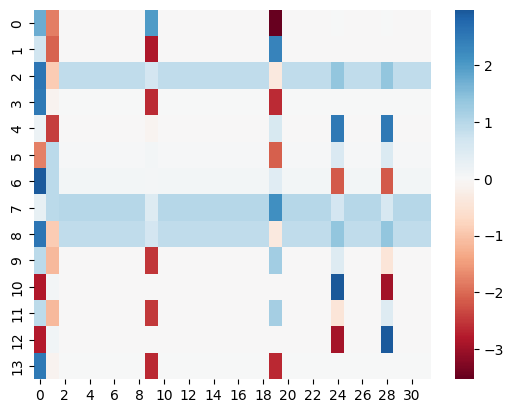

In [35]:
sns.heatmap(
    model.target_model.l1.weight.data,
    cmap="RdBu",
    center=0,
)
plt.show()

In [36]:
ci[task_ids == 0].mean(0).sort(descending=True)

torch.return_types.sort(
values=tensor([4.9733e-01, 2.5193e-01, 2.5067e-01, 2.0731e-01, 2.0248e-01, 1.4210e-01,
        1.3366e-03, 3.6960e-04, 5.5752e-05, 3.2710e-05, 1.4878e-06, 8.6387e-07,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        

In [37]:
(ci[task_ids == 0].mean(0) - ci.mean(0)).sort(descending=True)

torch.return_types.sort(
values=tensor([ 6.7410e-02,  6.7073e-02,  5.5471e-02,  5.4180e-02,  1.2957e-02,
         3.5764e-04,  7.7399e-05,  1.4918e-05,  3.9810e-07,  2.3115e-07,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00

In [38]:
task_ids

tensor([0, 0, 1,  ..., 1, 0, 1])

<Axes: >

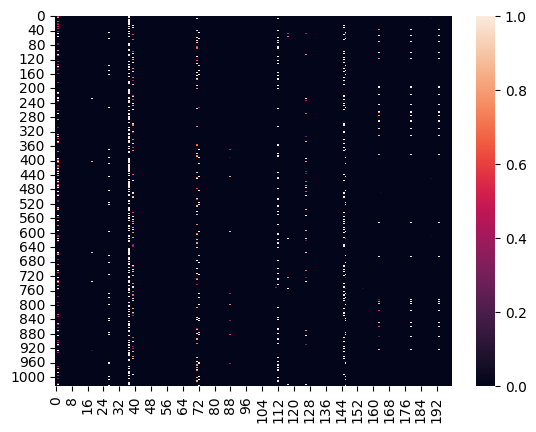

In [39]:
sns.heatmap(ci.detach())

In [40]:
ci.mean(0).sort()

torch.return_types.sort(
values=tensor([0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        

In [41]:
component_ci_threshold = 0.9
mask_infos = make_mask_infos(
    component_masks={k: (v > component_ci_threshold).float() for k, v in ci_dict.items()},
    routing_masks="all",
)

logits_using_components = model(batch, cache_type="input", mask_infos=mask_infos).output
loss_using_components = loss = F.cross_entropy(logits_using_components, targets)
print(f"{loss_using_components=}")

loss_using_components=tensor(7.1782e-05, grad_fn=<NllLossBackward0>)


In [42]:
targets

tensor([1, 0, 1,  ..., 0, 1, 1])

In [43]:
ci[3]

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.7215,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 

In [44]:
logits_using_components

tensor([[-22.1947,   4.2517],
        [ -4.7948, -15.3691],
        [-11.1995,   8.9094],
        ...,
        [ -6.3686, -14.9187],
        [-24.6936,   5.1729],
        [-17.5765,   5.1465]], grad_fn=<MmBackward0>)

In [79]:
from load_spd_model2 import load_spd_models_for_checkpoints, get_steps_to_upload

In [83]:
train_config = TrainConfig()
checkpoints_config = UploadCheckpointsConfig()

models = load_spd_models_for_checkpoints(train_config, checkpoints_config)
steps_list = get_steps_to_upload(train_config, checkpoints_config)

Loaded step 0 from cache
Loaded step 10000 from cache
Loaded step 20000 from cache
Loaded step 30000 from cache
Loaded step 40000 from cache
Loaded step 50000 from cache
Loaded step 60000 from cache
Loaded step 70000 from cache
Loaded step 80000 from cache
Loaded step 90000 from cache
Loaded step 100000 from cache


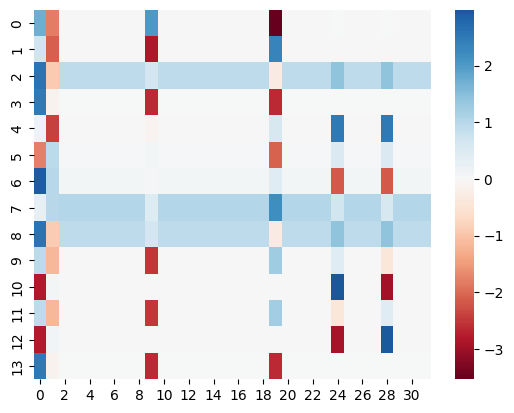

In [91]:
components = models[steps_list[10]].model.components['l1']
sns.heatmap(
    einops.einsum(
        components.V[:, :],
        components.U[:],
        "d_in c, c d_out -> d_out d_in",
    ).detach(),
    cmap="RdBu",
    center=0,
)
plt.show()

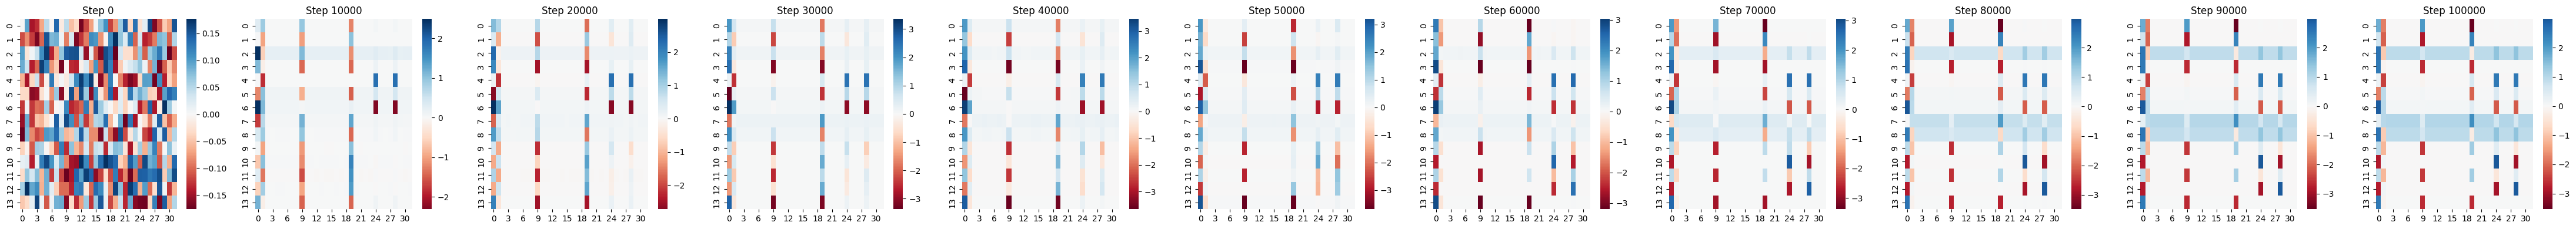

In [92]:
fig, axes = plt.subplots(1, 11, figsize=(44, 4))
for i, step in enumerate(steps_list):
    components = models[step].model.components['l1']
    sns.heatmap(
        einops.einsum(
            components.V[:, :],
            components.U[:],
            "d_in c, c d_out -> d_out d_in",
        ).detach(),
        cmap="RdBu",
        center=0,
        ax=axes[i],
    )
    axes[i].set_title(f"Step {step}")
plt.tight_layout()
plt.show()

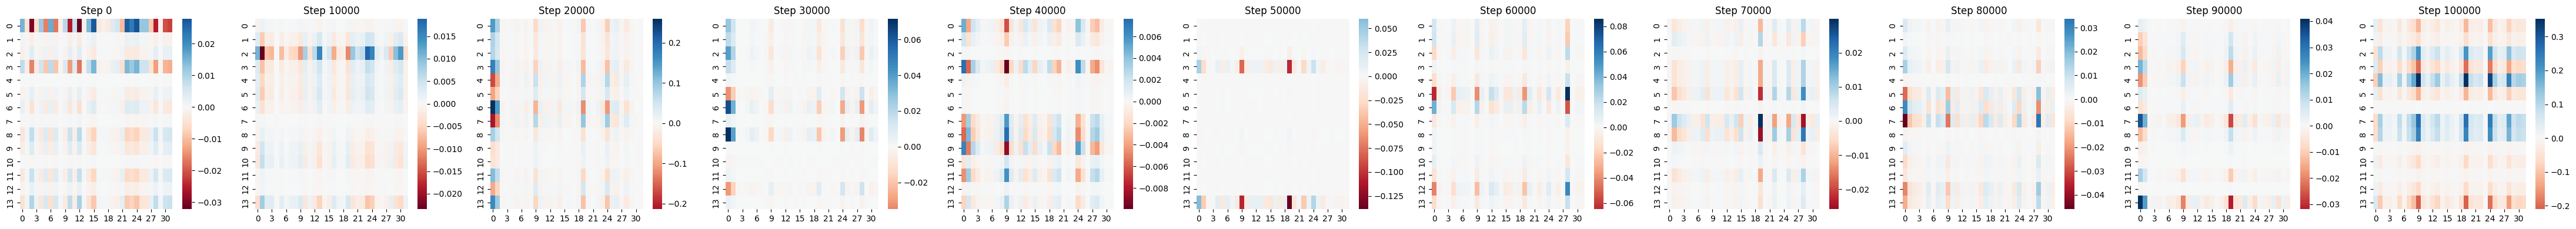

In [93]:
fig, axes = plt.subplots(1, 11, figsize=(44, 4))
for i, step in enumerate(steps_list):
    components = models[step].model.components['l1']
    sns.heatmap(
        einops.einsum(
            components.V[:, 0],
            components.U[0],
            "d_in, d_out -> d_out d_in",
        ).detach(),
        cmap="RdBu",
        center=0,
        ax=axes[i],
    )
    axes[i].set_title(f"Step {step}")
plt.tight_layout()
plt.show()